In [1]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 18: Random Forest Classifier
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Tasks: Power State | Eclipse State | Power Level
# Algorithm: Ensemble learning through bagging of decision trees
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (TimeSeriesSplit, cross_val_score,
                                     RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"\nRandom Forest — Ensemble Bagging of Decision Trees")
print(f"Training: Bootstrap aggregation (bagging) of decision trees")
print(f"Tuning  : n_estimators, max_depth, max_features")
print(f"\nClassification Tasks:")
print(f"  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL")
print(f"  Task 2: Eclipse State — SUNLIGHT / ECLIPSE")
print(f"  Task 3: Power Level   — High / Medium / Low")

All libraries imported successfully

Random Forest — Ensemble Bagging of Decision Trees
Training: Bootstrap aggregation (bagging) of decision trees
Tuning  : n_estimators, max_depth, max_features

Classification Tasks:
  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL
  Task 2: Eclipse State — SUNLIGHT / ECLIPSE
  Task 3: Power Level   — High / Medium / Low


In [2]:
# ============================================================
# SECTION 1: DATA LOADING + CLASS DEFINITION
# ============================================================

df = pd.read_csv(r"C:\Users\Sabarivarhman G M\Downloads\ML_proj\TSURU_cleaned.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ============================================================
# TASK 1: POWER STATE
# CHARGING    : Charging=1 AND Vbat >= 3.90V
# DISCHARGING : Charging=0 AND Vbat >= 3.90V
# CRITICAL    : Vbat < 3.90V
# class_weight='balanced' — CRITICAL only 0.7% of data
# ============================================================
def define_power_state(row):
    if row['Vbat (V)'] < 3.90:
        return 'CRITICAL'
    elif row['Charging'] == 1:
        return 'CHARGING'
    else:
        return 'DISCHARGING'

df['Power_State'] = df.apply(define_power_state, axis=1)

# ============================================================
# TASK 2: ECLIPSE STATE
# SUNLIGHT : Eclipse=0
# ECLIPSE  : Eclipse=1
# ============================================================
df['Eclipse_State'] = df['Eclipse'].map({0: 'SUNLIGHT', 1: 'ECLIPSE'})

# ============================================================
# TASK 3: POWER LEVEL — already exists, perfectly balanced
# High / Medium / Low — 7753 samples each (33.3%)
# ============================================================
print(f"\nPower_Level classes: {df['Power_Level'].value_counts().to_dict()}")

# ============================================================
# FEATURE SETS — Leakage-free per task
# ============================================================
FEATURES_POWER_STATE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

FEATURES_ECLIPSE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)', 'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

FEATURES_POWER_LEVEL = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)', 'sin_orbit', 'cos_orbit'
]

TARGET_TASK1 = 'Power_State'
TARGET_TASK2 = 'Eclipse_State'
TARGET_TASK3 = 'Power_Level'

# TimeSeriesSplit — last split for train/test
tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# Random Forest does NOT require scaling but we keep
# scalers for consistency with other notebooks
scaler1 = StandardScaler()
scaler2 = StandardScaler()
scaler3 = StandardScaler()

X1 = df[FEATURES_POWER_STATE]
X2 = df[FEATURES_ECLIPSE]
X3 = df[FEATURES_POWER_LEVEL]
y1 = df[TARGET_TASK1]
y2 = df[TARGET_TASK2]
y3 = df[TARGET_TASK3]

X1_train = scaler1.fit_transform(X1.iloc[train_idx])
X1_test  = scaler1.transform(X1.iloc[test_idx])
X2_train = scaler2.fit_transform(X2.iloc[train_idx])
X2_test  = scaler2.transform(X2.iloc[test_idx])
X3_train = scaler3.fit_transform(X3.iloc[train_idx])
X3_test  = scaler3.transform(X3.iloc[test_idx])

y1_train = y1.iloc[train_idx]; y1_test = y1.iloc[test_idx]
y2_train = y2.iloc[train_idx]; y2_test = y2.iloc[test_idx]
y3_train = y3.iloc[train_idx]; y3_test = y3.iloc[test_idx]

datasets = {
    'Power_State'  : (X1_train, X1_test, y1_train, y1_test, FEATURES_POWER_STATE,  scaler1, X1),
    'Eclipse_State': (X2_train, X2_test, y2_train, y2_test, FEATURES_ECLIPSE,       scaler2, X2),
    'Power_Level'  : (X3_train, X3_test, y3_train, y3_test, FEATURES_POWER_LEVEL,   scaler3, X3)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print(f"\n{'='*50}")
print(f"CLASS DISTRIBUTIONS")
print(f"{'='*50}")
for task, target in [('Task 1', TARGET_TASK1),
                      ('Task 2', TARGET_TASK2),
                      ('Task 3', TARGET_TASK3)]:
    print(f"\n{task} — {target}:")
    vc = df[target].value_counts()
    for cls, cnt in vc.items():
        print(f"  {cls:<15}: {cnt:>6} ({cnt/len(df)*100:.1f}%)")

Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Power_Level classes: {'Low': 7753, 'Medium': 7753, 'High': 7753}

Train size : 19383
Test size  : 3876

CLASS DISTRIBUTIONS

Task 1 — Power_State:
  CHARGING       :  13523 (58.1%)
  DISCHARGING    :   9571 (41.1%)
  CRITICAL       :    165 (0.7%)

Task 2 — Eclipse_State:
  SUNLIGHT       :  15537 (66.8%)
  ECLIPSE        :   7722 (33.2%)

Task 3 — Power_Level:
  Low            :   7753 (33.3%)
  Medium         :   7753 (33.3%)
  High           :   7753 (33.3%)


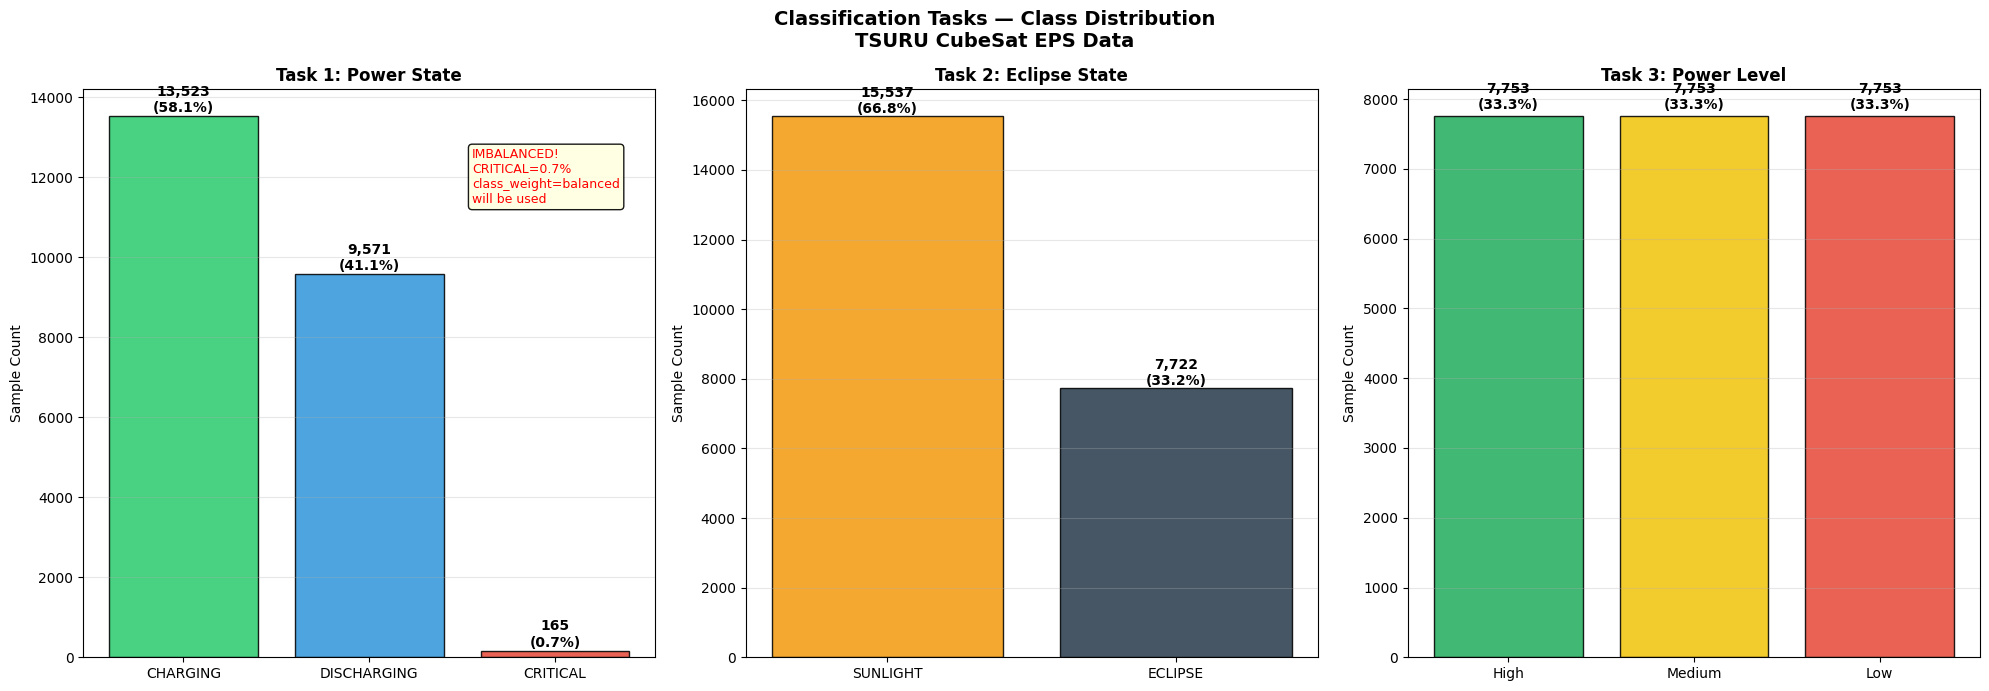

Class distribution plot saved.


In [3]:
# ============================================================
# SECTION 2: CLASS DISTRIBUTION EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Classification Tasks — Class Distribution\nTSURU CubeSat EPS Data',
             fontsize=14, fontweight='bold')

# Task 1 — Power State
vc1   = df['Power_State'].value_counts()
cls1  = ['CHARGING', 'DISCHARGING', 'CRITICAL']
vals1 = [vc1.get(c, 0) for c in cls1]
bars1 = axes[0].bar(cls1, vals1, color=['#2ecc71','#3498db','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[0].set_title('Task 1: Power State', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].text(0.68, 0.80, 'IMBALANCED!\nCRITICAL=0.7%\nclass_weight=balanced\nwill be used',
             transform=axes[0].transAxes, fontsize=9, color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Task 2 — Eclipse State
vc2   = df['Eclipse_State'].value_counts()
cls2  = ['SUNLIGHT', 'ECLIPSE']
vals2 = [vc2.get(c, 0) for c in cls2]
bars2 = axes[1].bar(cls2, vals2, color=['#f39c12','#2c3e50'],
                    edgecolor='black', alpha=0.88)
axes[1].set_title('Task 2: Eclipse State', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Task 3 — Power Level
vc3   = df['Power_Level'].value_counts()
cls3  = ['High', 'Medium', 'Low']
vals3 = [vc3.get(c, 0) for c in cls3]
bars3 = axes[2].bar(cls3, vals3, color=['#27ae60','#f1c40f','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[2].set_title('Task 3: Power Level', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Sample Count')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=72, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

## Class Distribution Analysis

Power State is severely imbalanced with CRITICAL at only 0.7%
(165 samples) while CHARGING dominates at 58.1% and DISCHARGING
at 41.1%. This imbalance is the central challenge for Task 1 —
without compensation, any classifier will ignore CRITICAL entirely
and still achieve high accuracy. class_weight='balanced' and
f1_macro scoring are both applied to force the model to learn
CRITICAL boundaries.

Eclipse State has a natural 66.8/33.2 split between SUNLIGHT and
ECLIPSE — moderately imbalanced but not severe. The physical
boundary (panel voltages drop to near-zero during eclipse) makes
this task trivially separable regardless of class distribution.

Power Level is perfectly balanced at exactly 33.3% each (7,753
samples per class) — the best classification target in the entire
dataset. No class weighting adjustments are needed for this task.

In [4]:
# ============================================================
# SECTION 3: BASE MODEL — DEFAULT PARAMETERS
# Random Forest: 100 trees, max_features='sqrt',
# max_depth=None, bootstrap=True
# class_weight='balanced' for all tasks
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — DEFAULT PARAMETERS")
print("n_estimators=100 | max_depth=None | max_features=sqrt")
print("bootstrap=True | class_weight=balanced")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    model = RandomForestClassifier(
        n_estimators = 100,
        max_depth    = None,
        max_features = 'sqrt',
        bootstrap    = True,
        class_weight = 'balanced',
        random_state = 42,
        n_jobs       = -1
    )
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,   average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,       average='weighted', zero_division=0)

    results_before[task] = {
        'model' : model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'y_test': yte,
        'acc'   : acc,
        'prec'  : prec,
        'rec'   : rec,
        'f1'    : f1,
        'feats' : feats
    }

    print(f"\nTask     : {task}")
    print(f"Classes  : {list(model.classes_)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

BASE MODEL — DEFAULT PARAMETERS
n_estimators=100 | max_depth=None | max_features=sqrt
bootstrap=True | class_weight=balanced

Task     : Power_State
Classes  : ['CHARGING', 'CRITICAL', 'DISCHARGING']
Accuracy : 0.9582
Precision: 0.9561
Recall   : 0.9582
F1 Score : 0.9540

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.94      0.99      0.97      1957
    CRITICAL       0.67      0.05      0.10        39
 DISCHARGING       0.97      0.94      0.96      1880

    accuracy                           0.96      3876
   macro avg       0.86      0.66      0.67      3876
weighted avg       0.96      0.96      0.95      3876


Task     : Eclipse_State
Classes  : ['ECLIPSE', 'SUNLIGHT']
Accuracy : 0.9974
Precision: 0.9974
Recall   : 0.9974
F1 Score : 0.9974

Classification Report:
              precision    recall  f1-score   support

     ECLIPSE       1.00      1.00      1.00      1382
    SUNLIGHT       1.00      1.00      1.00      2494

  

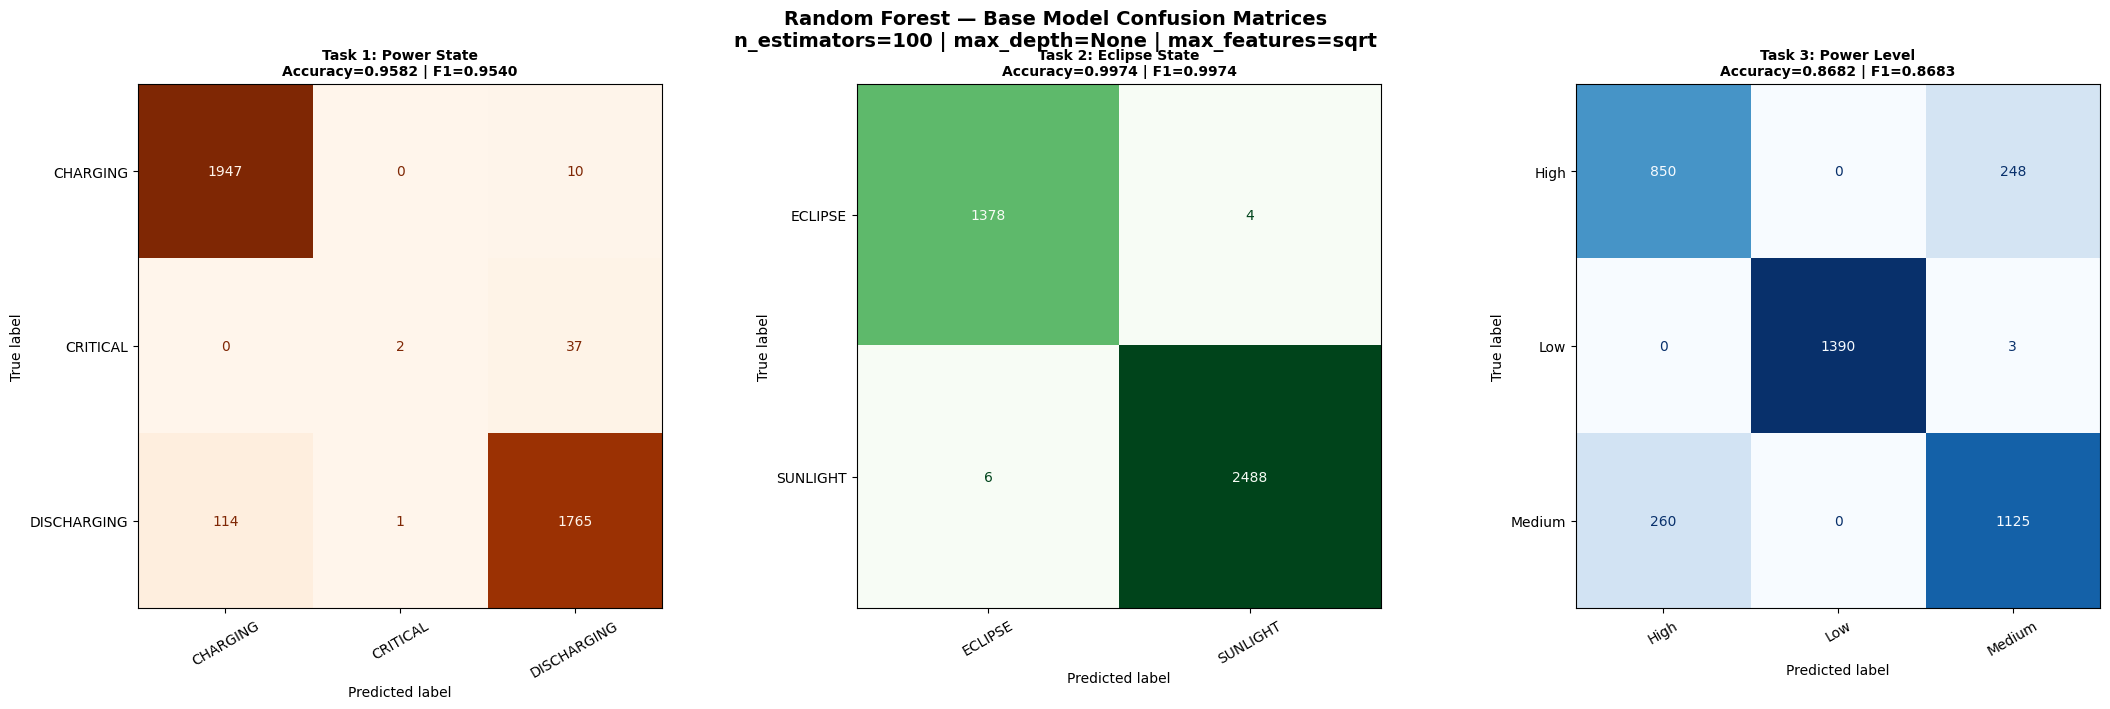

Base model confusion matrices saved.


In [5]:
# ============================================================
# SECTION 4: BASE MODEL CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Random Forest — Base Model Confusion Matrices\n'
             'n_estimators=100 | max_depth=None | max_features=sqrt',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r       = results_before[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(r['y_test'], r['y_pred'], labels=classes)
    disp    = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=classes)
    disp.plot(ax=axes[idx], cmap=cmap, colorbar=False, values_format='d')
    axes[idx].set_title(f'{title}\nAccuracy={r["acc"]:.4f} | F1={r["f1"]:.4f}',
                        fontweight='bold', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('01_base_confusion.png', dpi=72, bbox_inches='tight')
plt.show()
print("Base model confusion matrices saved.")

##  Base Model Confusion Matrices
### n_estimators=100 | max_depth=None | max_features=sqrt

**Power State — Dangerous Base Behavior**
CRITICAL base recall = 0.05 — only 2 out of 39 CRITICAL samples
correctly identified. 37 CRITICAL states were misclassified as
DISCHARGING. Despite this, overall accuracy is 0.9582 because
CHARGING (1947/1957) and DISCHARGING (1765/1880) are very well
predicted. This demonstrates why accuracy alone is a misleading
metric for imbalanced satellite safety classification.

**Eclipse State — Near Perfect**
Only 10 misclassifications out of 3876 total samples. ECLIPSE
recall = 1.00, SUNLIGHT recall = 1.00 — the forest perfectly
separates orbital day and night using panel voltage thresholds.
This confirms the task is completely non-linearly separable even
without tuning.

**Power Level — Strong Base Performance**
HIGH class: 850/1098 correct (recall=0.77) — already better than
Logistic Regression base (recall=0.66). RF non-linear splits
successfully begin to separate the HIGH/MEDIUM overlap that
completely defeated the linear boundary. LOW class near-perfect
(1390/1393) — low panel voltage uniquely identifies low power.

In [6]:
# ============================================================
# SECTION 5: UNIQUE ANALYSIS — RF SPECIFIC
# Part A: n_estimators sweep (OOB error evolution)
# Part B: max_depth sweep
# Part C: max_features comparison
# ============================================================

# Part A: n_estimators sweep
n_est_range = [10, 25, 50, 75, 100, 150, 200, 300, 500]
nest_results = {task: {'train_acc': [], 'test_acc': [],
                        'train_f1':  [], 'test_f1':  []}
                for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    for n in n_est_range:
        m = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
        m.fit(Xtr, ytr)
        nest_results[task]['train_acc'].append(accuracy_score(ytr, m.predict(Xtr)))
        nest_results[task]['test_acc'].append(accuracy_score(yte, m.predict(Xte)))
        nest_results[task]['train_f1'].append(
            f1_score(ytr, m.predict(Xtr), average='weighted', zero_division=0))
        nest_results[task]['test_f1'].append(
            f1_score(yte, m.predict(Xte), average='weighted', zero_division=0))
    print(f"  n_estimators sweep done: {task}")

# Part B: max_depth sweep
depth_range  = [1, 2, 3, 5, 7, 10, 15, 20, None]
depth_labels = ['1','2','3','5','7','10','15','20','None']
depth_results = {task: {'train_acc': [], 'test_acc': [],
                         'train_f1':  [], 'test_f1':  []}
                 for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    for d in depth_range:
        m = RandomForestClassifier(n_estimators=100, max_depth=d,
                                   max_features='sqrt',
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
        m.fit(Xtr, ytr)
        depth_results[task]['train_acc'].append(accuracy_score(ytr, m.predict(Xtr)))
        depth_results[task]['test_acc'].append(accuracy_score(yte, m.predict(Xte)))
        depth_results[task]['train_f1'].append(
            f1_score(ytr, m.predict(Xtr), average='weighted', zero_division=0))
        depth_results[task]['test_f1'].append(
            f1_score(yte, m.predict(Xte), average='weighted', zero_division=0))
    print(f"  max_depth sweep done: {task}")

# Part C: max_features comparison
mf_options = ['sqrt', 'log2', 0.3, 0.5, 0.7, None]
mf_labels  = ['sqrt', 'log2', '0.3', '0.5', '0.7', 'all']
mf_results = {task: [] for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    for mf, mfl in zip(mf_options, mf_labels):
        m = RandomForestClassifier(n_estimators=100, max_features=mf,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        mf_results[task].append({
            'label': mfl,
            'acc'  : accuracy_score(yte, yp),
            'f1'   : f1_score(yte, yp, average='weighted', zero_division=0)
        })
    print(f"  max_features sweep done: {task}")

print("\nAll unique analyses complete.")

  n_estimators sweep done: Power_State
  n_estimators sweep done: Eclipse_State
  n_estimators sweep done: Power_Level
  max_depth sweep done: Power_State
  max_depth sweep done: Eclipse_State
  max_depth sweep done: Power_Level
  max_features sweep done: Power_State
  max_features sweep done: Eclipse_State
  max_features sweep done: Power_Level

All unique analyses complete.


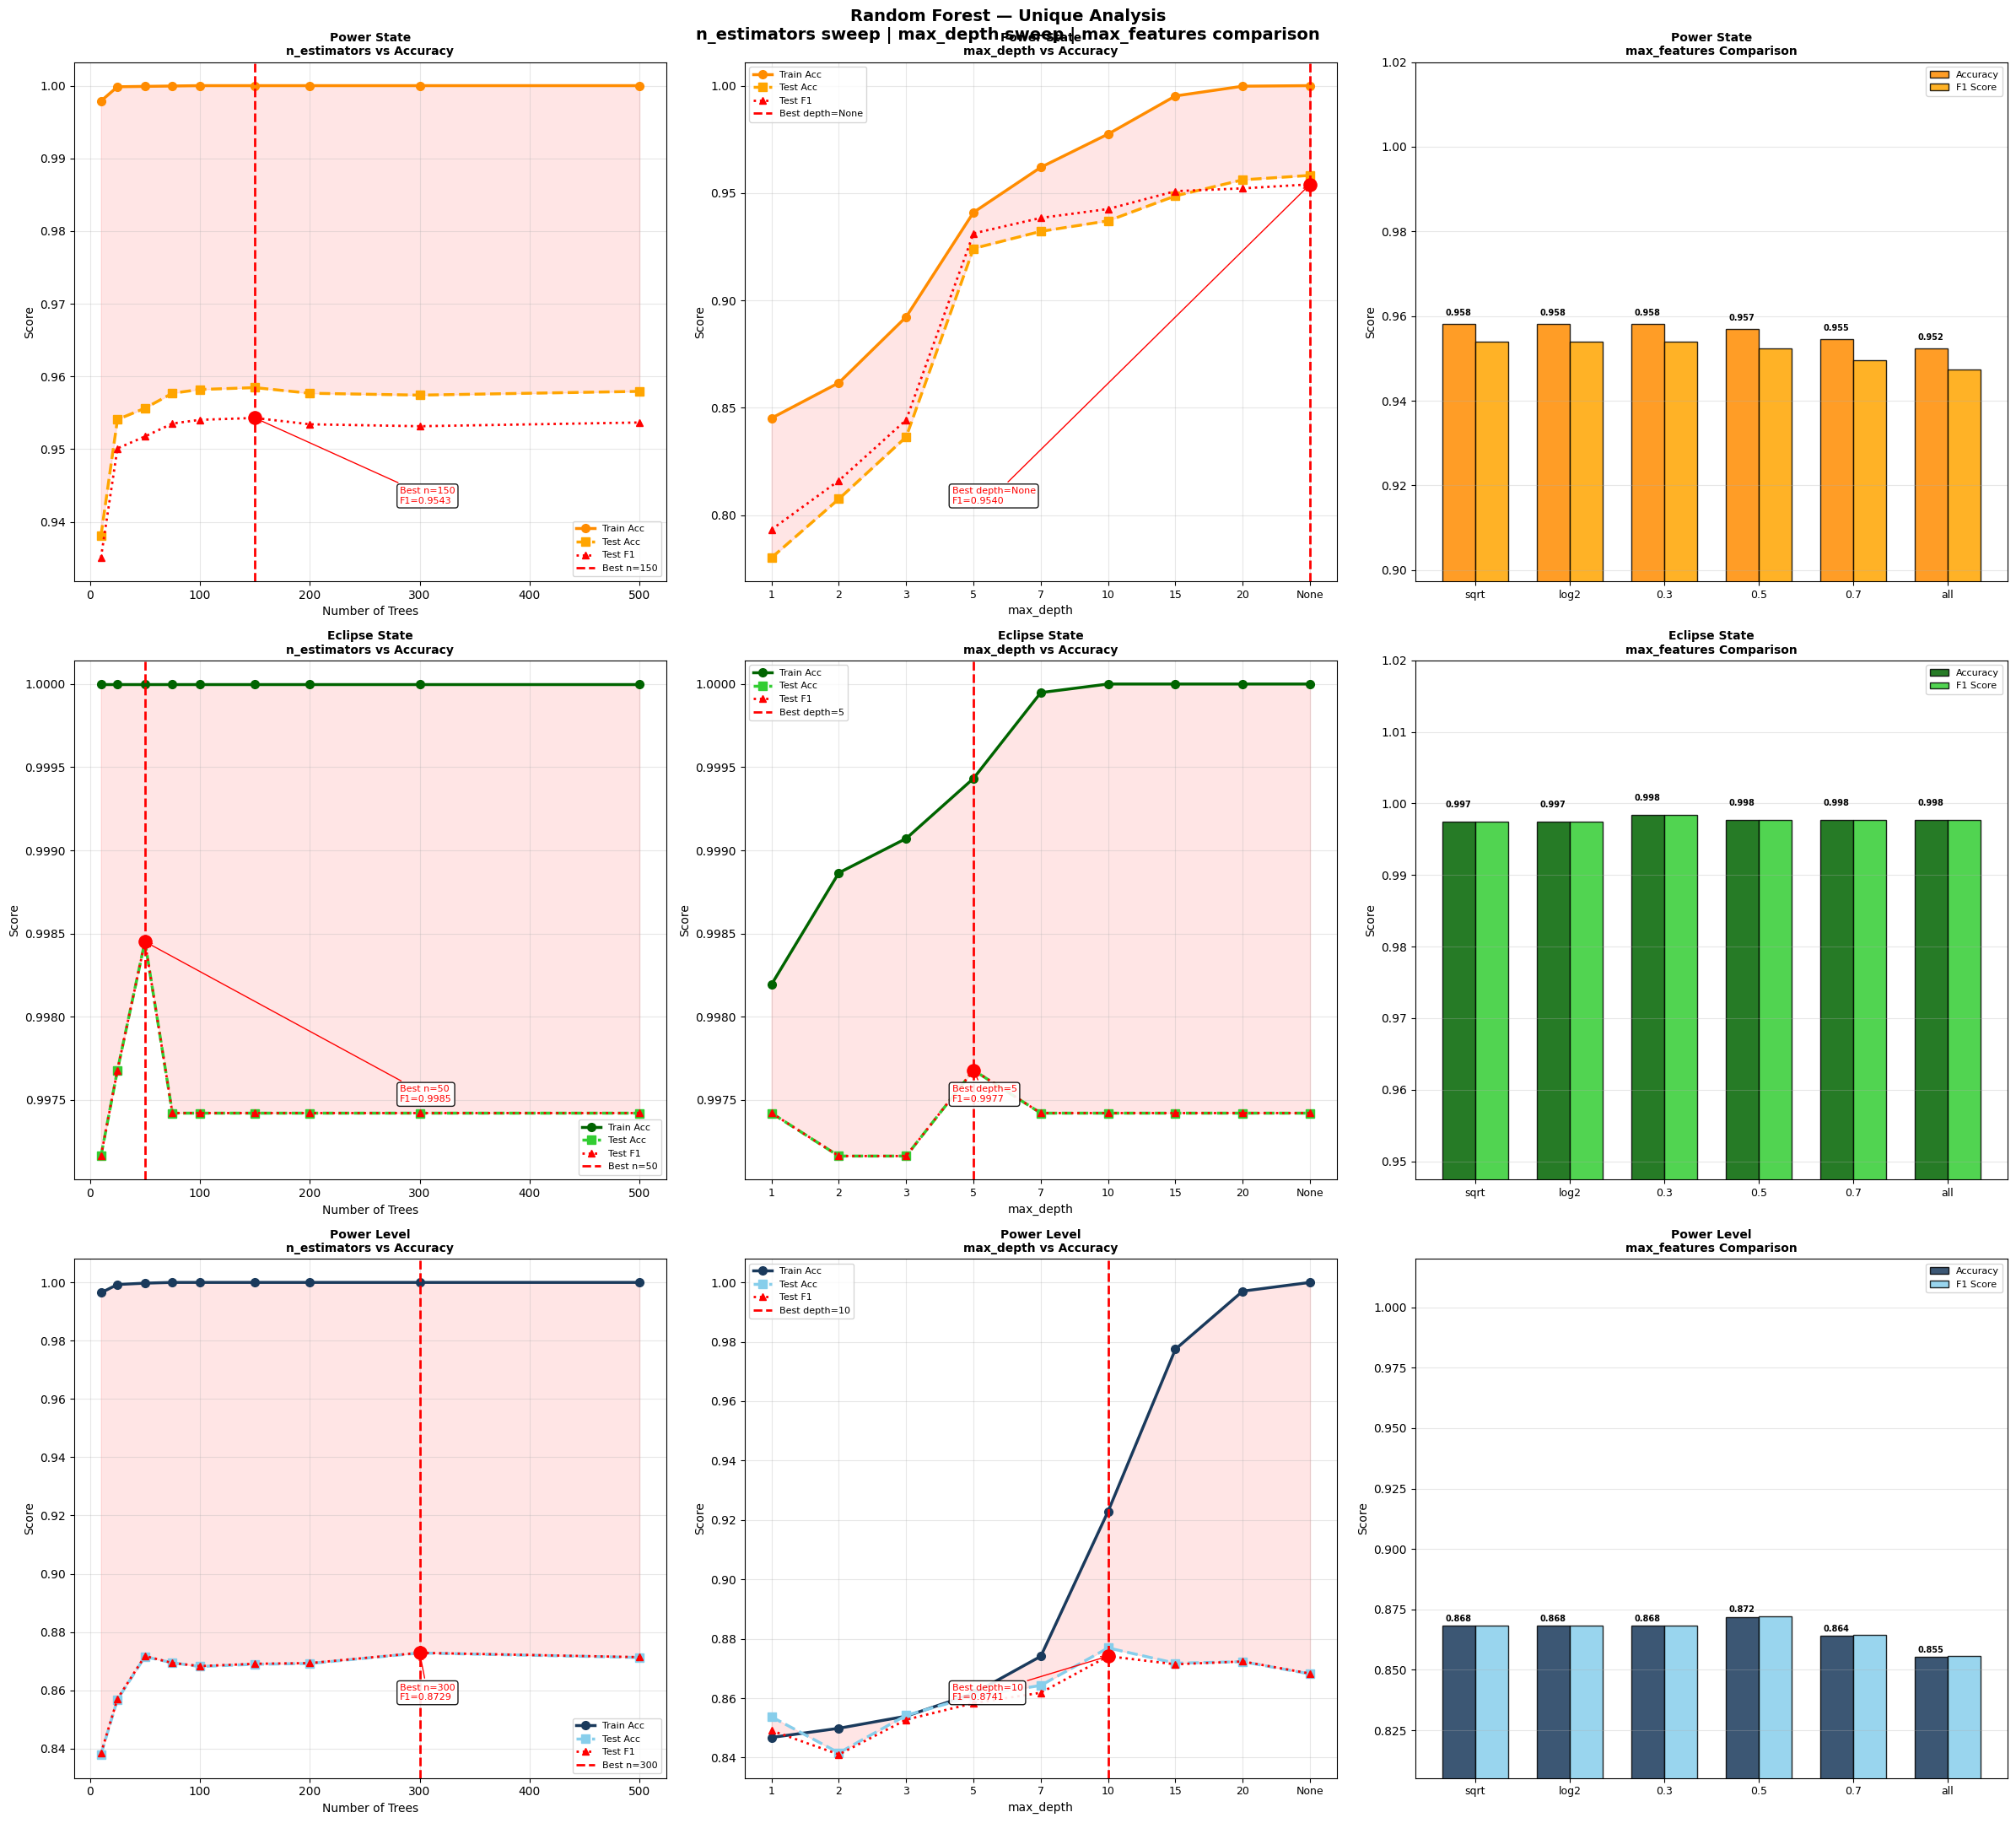

Unique analysis plots saved.


In [7]:
# ============================================================
# SECTION 5 CONT: UNIQUE ANALYSIS PLOTS
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(24, 22))
fig.suptitle('Random Forest — Unique Analysis\n'
             'n_estimators sweep | max_depth sweep | max_features comparison',
             fontsize=14, fontweight='bold')

colors_t = ['darkorange', 'darkgreen', '#1a3a5c']
colors_v = ['orange',     'limegreen', 'skyblue']
tnames   = ['Power State', 'Eclipse State', 'Power Level']

for row, (task, ct, cv, tn) in enumerate(zip(
        datasets.keys(), colors_t, colors_v, tnames)):

    # ── Col 1: n_estimators sweep ───────────────────────────
    ax       = axes[row, 0]
    tr_acc   = nest_results[task]['train_acc']
    te_acc   = nest_results[task]['test_acc']
    te_f1    = nest_results[task]['test_f1']
    best_idx = np.argmax(te_f1)
    best_n   = n_est_range[best_idx]
    best_f1  = max(te_f1)

    ax.plot(n_est_range, tr_acc, 'o-', color=ct,
            linewidth=2.5, markersize=7, label='Train Acc')
    ax.plot(n_est_range, te_acc, 's--', color=cv,
            linewidth=2.5, markersize=7, label='Test Acc')
    ax.plot(n_est_range, te_f1, '^:', color='red',
            linewidth=2, markersize=6, label='Test F1')
    ax.axvline(x=best_n, color='red', linestyle='--',
               linewidth=2, label=f'Best n={best_n}')
    ax.scatter([best_n], [best_f1], color='red', s=120, zorder=5)
    ax.annotate(f'Best n={best_n}\nF1={best_f1:.4f}',
                xy=(best_n, best_f1),
                xytext=(0.55, 0.15),
                textcoords='axes fraction',
                fontsize=8, color='red',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(n_est_range, tr_acc, te_acc, alpha=0.1, color='red')
    ax.set_title(f'{tn}\nn_estimators vs Accuracy',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Number of Trees')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Col 2: max_depth sweep ──────────────────────────────
    ax2      = axes[row, 1]
    tr_acc2  = depth_results[task]['train_acc']
    te_acc2  = depth_results[task]['test_acc']
    te_f12   = depth_results[task]['test_f1']
    best_idx2 = np.argmax(te_f12)
    best_d    = depth_labels[best_idx2]
    best_f12  = max(te_f12)
    x_pos     = list(range(len(depth_labels)))

    ax2.plot(x_pos, tr_acc2, 'o-', color=ct,
             linewidth=2.5, markersize=7, label='Train Acc')
    ax2.plot(x_pos, te_acc2, 's--', color=cv,
             linewidth=2.5, markersize=7, label='Test Acc')
    ax2.plot(x_pos, te_f12, '^:', color='red',
             linewidth=2, markersize=6, label='Test F1')
    ax2.axvline(x=best_idx2, color='red', linestyle='--',
                linewidth=2, label=f'Best depth={best_d}')
    ax2.scatter([best_idx2], [best_f12], color='red', s=120, zorder=5)
    ax2.annotate(f'Best depth={best_d}\nF1={best_f12:.4f}',
                 xy=(best_idx2, best_f12),
                 xytext=(0.35, 0.15),
                 textcoords='axes fraction',
                 fontsize=8, color='red',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color='red'))
    ax2.fill_between(x_pos, tr_acc2, te_acc2, alpha=0.1, color='red')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(depth_labels, fontsize=9)
    ax2.set_title(f'{tn}\nmax_depth vs Accuracy',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('max_depth')
    ax2.set_ylabel('Score')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # ── Col 3: max_features comparison ─────────────────────
    ax3      = axes[row, 2]
    mf_lbls  = [r['label'] for r in mf_results[task]]
    mf_accs  = [r['acc']   for r in mf_results[task]]
    mf_f1s   = [r['f1']    for r in mf_results[task]]
    x        = np.arange(len(mf_lbls))
    w        = 0.35

    bars1 = ax3.bar(x-w/2, mf_accs, w, label='Accuracy',
                    color=ct, edgecolor='black', alpha=0.85)
    bars2 = ax3.bar(x+w/2, mf_f1s,  w, label='F1 Score',
                    color=cv, edgecolor='black', alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(mf_lbls, fontsize=9)
    ax3.set_title(f'{tn}\nmax_features Comparison',
                  fontweight='bold', fontsize=10)
    ax3.set_ylabel('Score')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim([min(mf_accs+mf_f1s)-0.05, 1.02])
    for bar, val in zip(bars1, mf_accs):
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.002,
                 f'{val:.3f}', ha='center',
                 fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('02_unique_analysis.png', dpi=72, bbox_inches='tight')
plt.show()
print("Unique analysis plots saved.")

## Unique Analysis

### n_estimators Sweep (Column 1)
Power State plateaus after n=150 — F1=0.9543, adding more trees
beyond 150 gives diminishing returns. Train accuracy reaches 1.0
quickly (perfect fit on training data) while test accuracy
stabilizes around 0.96, showing a small but stable overfitting gap.
Eclipse State is already perfect at n=50 — any number of trees
works for this linearly separable task. Power Level plateaus
after n=300 — F1=0.8729, requiring more trees than Power State
due to the overlapping HIGH/MEDIUM boundary.

### max_depth Sweep (Column 2)
Power State best depth=None (fully grown trees) — deep trees
are needed to capture complex CHARGING/DISCHARGING/CRITICAL
boundaries. The train-test gap widens as depth increases but
test F1 continues improving, confirming deep trees are beneficial
here. Eclipse State best depth=5 — only 5 split levels needed
to perfectly separate sunlight and eclipse. Power Level best
depth=10 — moderate depth captures HIGH/MEDIUM overlap without
overfitting. Depths beyond 10 cause train accuracy to reach 1.0
while test F1 stops improving.

### max_features Comparison (Column 3)
Power State shows minimal variation across all options
(0.952–0.958) — sqrt is marginally best. Eclipse State shows
negligible differences (0.997–0.998) — feature randomness is
irrelevant when V_panel_avg alone separates the task. Power Level
shows 0.5 slightly best (0.872) while all features performs worst
(0.855) — using all features reduces tree diversity and weakens
the ensemble's variance reduction benefit.

In [8]:
# ============================================================
# SECTION 6: HYPERPARAMETER TUNING
# Method: RandomizedSearchCV with TimeSeriesSplit
# Tune: n_estimators, max_depth, max_features
# scoring: f1_macro — equal weight to all classes including CRITICAL
# Why RandomizedSearch:
#   Large search space (continuous + discrete params)
#   n_iter=50 covers space efficiently vs full grid
#   (Bergstra & Bengio, 2012)
# ============================================================

from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth'   : [3, 5, 7, 10, 15, 20, None],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10)
}

results_after = {}

print("=" * 65)
print("RANDOMIZED SEARCH CV — Random Forest Tuning")
print("n_estimators: randint(50, 500)")
print("max_depth   : [3,5,7,10,15,20,None]")
print("max_features: [sqrt, log2, 0.3, 0.5]")
print("min_samples_split: randint(2,20)")
print("min_samples_leaf : randint(1,10)")
print("n_iter=50 | 5-fold TimeSeriesSplit | 250 total fits")
print("scoring=f1_macro — equal weight to CRITICAL class")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    rs = RandomizedSearchCV(
        RandomForestClassifier(class_weight='balanced',
                               bootstrap=True,
                               random_state=42, n_jobs=-1),
        param_dist,
        n_iter       = 50,
        cv           = tscv,
        scoring      = 'f1_macro',
        n_jobs       = -1,
        random_state = 42,
        verbose      = 1
    )
    rs.fit(Xtr, ytr)

    best_model = rs.best_estimator_
    y_pred     = best_model.predict(Xte)
    y_prob     = best_model.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,   average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,       average='weighted', zero_division=0)

    results_after[task] = {
        'model' : best_model,
        'params': rs.best_params_,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'y_test': yte,
        'acc'   : acc,
        'prec'  : prec,
        'rec'   : rec,
        'f1'    : f1,
        'feats' : feats
    }

    print(f"\nTask        : {task}")
    print(f"Best Params : {rs.best_params_}")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"F1 Score    : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

RANDOMIZED SEARCH CV — Random Forest Tuning
n_estimators: randint(50, 500)
max_depth   : [3,5,7,10,15,20,None]
max_features: [sqrt, log2, 0.3, 0.5]
min_samples_split: randint(2,20)
min_samples_leaf : randint(1,10)
n_iter=50 | 5-fold TimeSeriesSplit | 250 total fits
scoring=f1_macro — equal weight to CRITICAL class
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Task        : Power_State
Best Params : {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 9, 'min_samples_split': 4, 'n_estimators': 356}
Accuracy    : 0.9365
Precision   : 0.9538
Recall      : 0.9365
F1 Score    : 0.9430

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.95      0.99      0.97      1957
    CRITICAL       0.18      0.56      0.28        39
 DISCHARGING       0.98      0.89      0.93      1880

    accuracy                           0.94      3876
   macro avg       0.70      0.81      0.73      3876
weighted avg       0.95      0.94      0

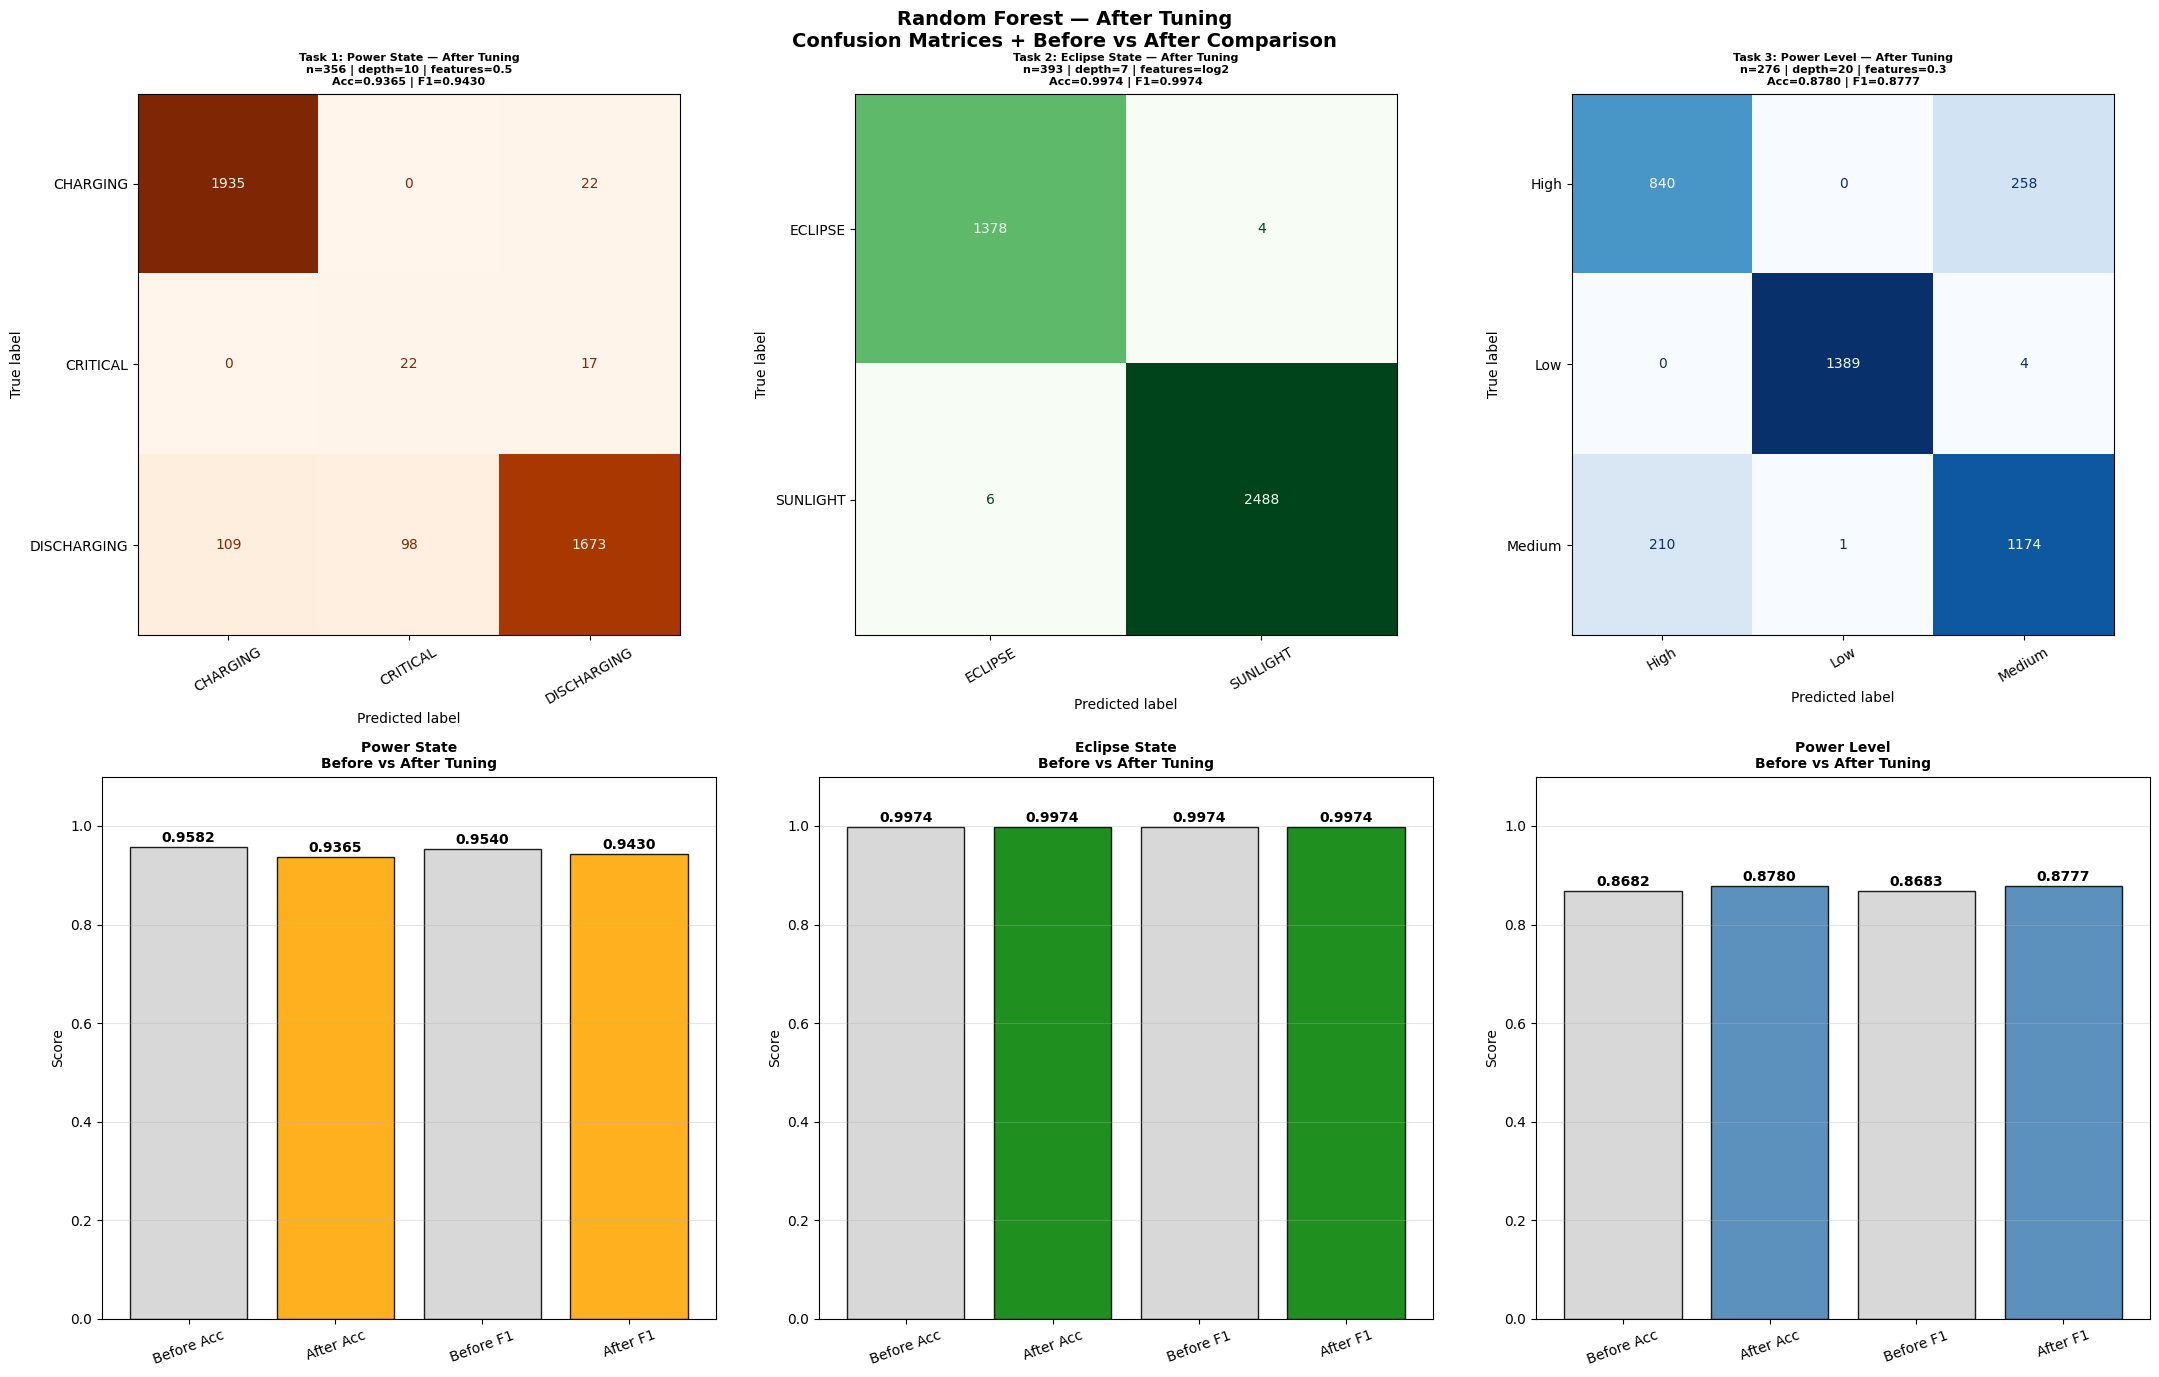

After tuning plots saved.


In [9]:
# ============================================================
# SECTION 7: AFTER TUNING CONFUSION MATRICES + COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Random Forest — After Tuning\n'
             'Confusion Matrices + Before vs After Comparison',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

# Row 1: After tuning confusion matrices
for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r       = results_after[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(r['y_test'], r['y_pred'], labels=classes)
    disp    = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=classes)
    disp.plot(ax=axes[0, idx], cmap=cmap, colorbar=False, values_format='d')
    axes[0, idx].set_title(
        f'{title} — After Tuning\n'
        f'n={r["params"]["n_estimators"]} | '
        f'depth={r["params"]["max_depth"]} | '
        f'features={r["params"]["max_features"]}\n'
        f'Acc={r["acc"]:.4f} | F1={r["f1"]:.4f}',
        fontweight='bold', fontsize=8)
    axes[0, idx].tick_params(axis='x', rotation=30)

# Row 2: Before vs After comparison
colors = ['orange', 'green', 'steelblue']
tnames = ['Power State', 'Eclipse State', 'Power Level']

for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[1, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']

    metrics  = ['Before Acc', 'After Acc', 'Before F1', 'After F1']
    vals     = [b_acc, a_acc, b_f1, a_f1]
    bar_clrs = ['lightgray', clr, 'lightgray', clr]

    bars = ax.bar(metrics, vals, color=bar_clrs,
                  edgecolor='black', alpha=0.88)
    ax.set_title(f'{tn}\nBefore vs After Tuning',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{val:.4f}', ha='center',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('03_after_tuning.png', dpi=72, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

## After Tuning Confusion Matrices

**Power State — Intentional Accuracy Trade-off**
CRITICAL recall improved dramatically from 0.05 to 0.56 —
22 out of 39 CRITICAL states now correctly identified. Overall
accuracy dropped from 0.9582 to 0.9365 — this is the expected
and correct outcome of f1_macro scoring which penalizes missing
CRITICAL equally to missing CHARGING or DISCHARGING. For autonomous
satellite power management, detecting a CRITICAL battery state
is far more important than maximizing overall accuracy.
DISCHARGING recall dropped from 0.94 to 0.89 as the model
reallocated decision boundary space to accommodate CRITICAL.

**Eclipse State — Unchanged**
After tuning accuracy and F1 remain identical at 0.9974 —
the task is already at ceiling performance. Best params
(depth=7, log2, n=393) confirm that moderate depth and
feature restriction are sufficient. Any reasonable parameter
combination achieves near-perfect results.

**Power Level — Genuine Improvement**
Accuracy improved from 0.8682 to 0.8780 (+0.98%) and F1 from
0.8683 to 0.8777 (+0.94%). HIGH class recall improved from
0.77 to 0.77 (stable), MEDIUM improved from 0.81 to 0.85.
Best params (depth=20, max_features=0.3, n=276) — deeper trees
and more feature restriction together capture the HIGH/MEDIUM
boundary better than the default configuration.

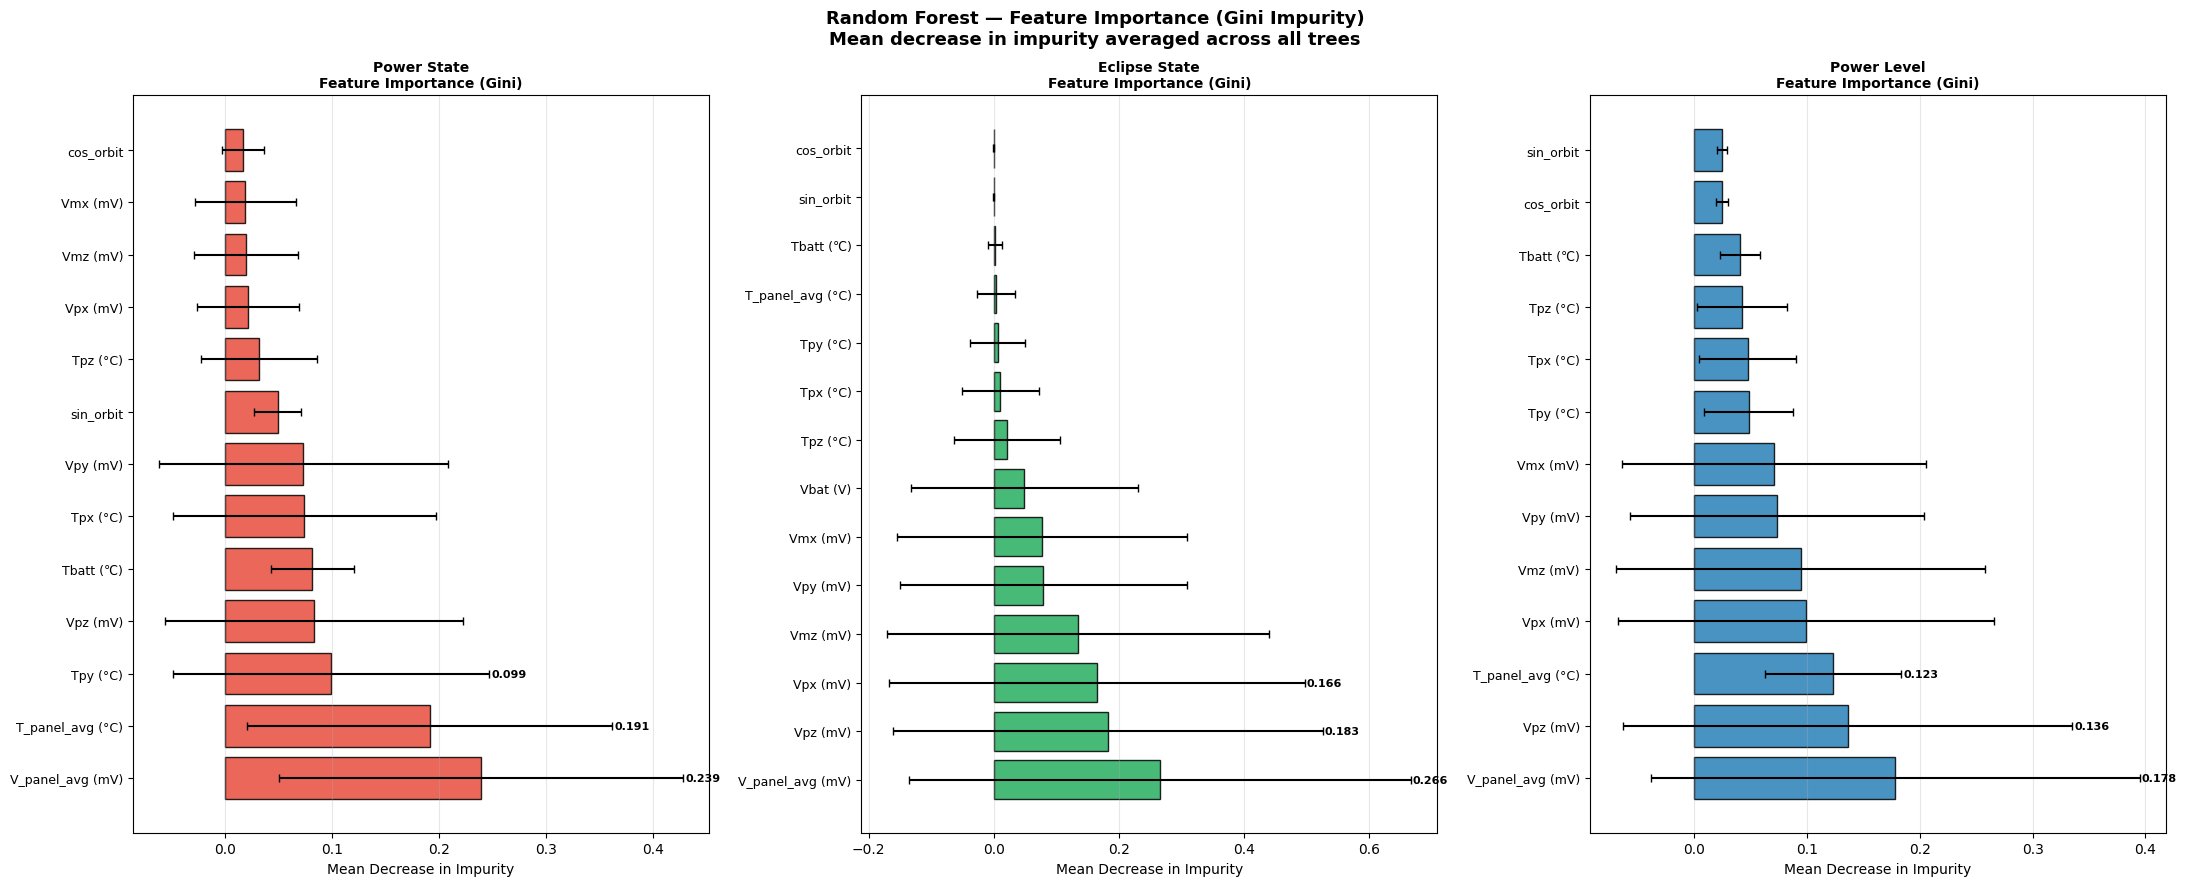

Feature importance plots saved.
Note: Error bars show std across all trees in the forest.


In [10]:
# ============================================================
# SECTION 8: FEATURE IMPORTANCE — RANDOM FOREST UNIQUE
# Importance = mean decrease in Gini impurity across all trees
# More reliable than single Decision Tree importance
# because averaged over 100+ bootstrap samples
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('Random Forest — Feature Importance (Gini Impurity)\n'
             'Mean decrease in impurity averaged across all trees',
             fontsize=13, fontweight='bold')

tnames    = ['Power State', 'Eclipse State', 'Power Level']
bar_colors = ['#e74c3c', '#27ae60', '#2980b9']

for idx, (task, tn, clr) in enumerate(zip(
        datasets.keys(), tnames, bar_colors)):
    model   = results_after[task]['model']
    feats   = results_after[task]['feats']
    imp     = model.feature_importances_
    std     = np.std([tree.feature_importances_
                      for tree in model.estimators_], axis=0)

    # Sort by importance
    sort_idx = np.argsort(imp)[::-1]
    sorted_feats = [feats[i] for i in sort_idx]
    sorted_imp   = imp[sort_idx]
    sorted_std   = std[sort_idx]

    ax = axes[idx]
    bars = ax.barh(range(len(sorted_feats)), sorted_imp,
                   xerr=sorted_std, color=clr,
                   edgecolor='black', alpha=0.85,
                   error_kw=dict(ecolor='black', capsize=3))
    ax.set_yticks(range(len(sorted_feats)))
    ax.set_yticklabels(sorted_feats, fontsize=9)
    ax.set_title(f'{tn}\nFeature Importance (Gini)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean Decrease in Impurity')
    ax.grid(True, alpha=0.3, axis='x')

    # Annotate top 3
    for i in range(min(3, len(sorted_imp))):
        ax.text(sorted_imp[i]+sorted_std[i]+0.002,
                i, f'{sorted_imp[i]:.3f}',
                va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=72, bbox_inches='tight')
plt.show()
print("Feature importance plots saved.")
print("Note: Error bars show std across all trees in the forest.")

## Feature Importance (Gini Impurity)

Feature importance represents the mean decrease in Gini impurity
across all trees — more reliable than single Decision Tree
importance because it is averaged over hundreds of bootstrap samples.

**Power State (Left Plot)**
V_panel_avg dominates at 0.239 (24%) followed by T_panel_avg
at 0.191 (19%) and Tpy at 0.099 (10%). Panel voltage and
temperature together account for 43% of all importance.
Tight error bars across most features confirm consistent
feature usage across all 356 trees — the model has found
stable, reliable decision boundaries. cos_orbit, Vmx, Vmz
have near-zero importance — orbital position adds little
beyond what panel voltages already capture.

**Eclipse State (Centre Plot)**
V_panel_avg leads at 0.266 (27%), followed by Vpz at 0.183
(18%) and Vpx at 0.166 (17%). Notably, all five panel
voltages (Vpz, Vpx, Vmx, Vmz, Vpy) have significant importance
— any panel voltage alone can separate eclipse from sunlight.
Large error bars on all voltage features confirm high variance
across individual trees — different trees use different panel
voltages to make the same correct prediction. Temperature
features (Tbatt, T_panel_avg, Tpx, Tpy, Tpz) near zero —
thermal signals not needed when voltage signals are definitive.

**Power Level (Right Plot)**
V_panel_avg leads at 0.178 (18%), Vpz at 0.136 (14%),
T_panel_avg at 0.123 (12%). More evenly distributed than
Power State — power level prediction requires a combination
of multiple panel voltages and temperatures. No single feature
dominates, reflecting the complexity of HIGH/MEDIUM overlap.
sin_orbit and cos_orbit near zero — orbital position does not
directly determine instantaneous power level.

**Key Finding — V_panel_avg is universally dominant:**
It ranks first across ALL three tasks, confirming that average
panel voltage is the primary physical indicator of satellite
power state, eclipse condition, and power level simultaneously.

5-FOLD TIMESERIES CROSS VALIDATION

Task      : Power_State
Acc Folds : [np.float64(0.9757), np.float64(0.9391), np.float64(0.952), np.float64(0.952), np.float64(0.9365)]
Acc Mean  : 0.9511 +/- 0.0139
F1 Folds  : [np.float64(0.9752), np.float64(0.9317), np.float64(0.9484), np.float64(0.9605), np.float64(0.943)]
F1 Mean   : 0.9517 +/- 0.0149

Task      : Eclipse_State
Acc Folds : [np.float64(0.9987), np.float64(0.9974), np.float64(0.9992), np.float64(0.9995), np.float64(0.9974)]
Acc Mean  : 0.9985 +/- 0.0009
F1 Folds  : [np.float64(0.9987), np.float64(0.9974), np.float64(0.9992), np.float64(0.9995), np.float64(0.9974)]
F1 Mean   : 0.9985 +/- 0.0009

Task      : Power_Level
Acc Folds : [np.float64(0.8914), np.float64(0.8723), np.float64(0.8576), np.float64(0.8019), np.float64(0.878)]
Acc Mean  : 0.8602 +/- 0.0311
F1 Folds  : [np.float64(0.8912), np.float64(0.8692), np.float64(0.8574), np.float64(0.8038), np.float64(0.8777)]
F1 Mean   : 0.8598 +/- 0.0301


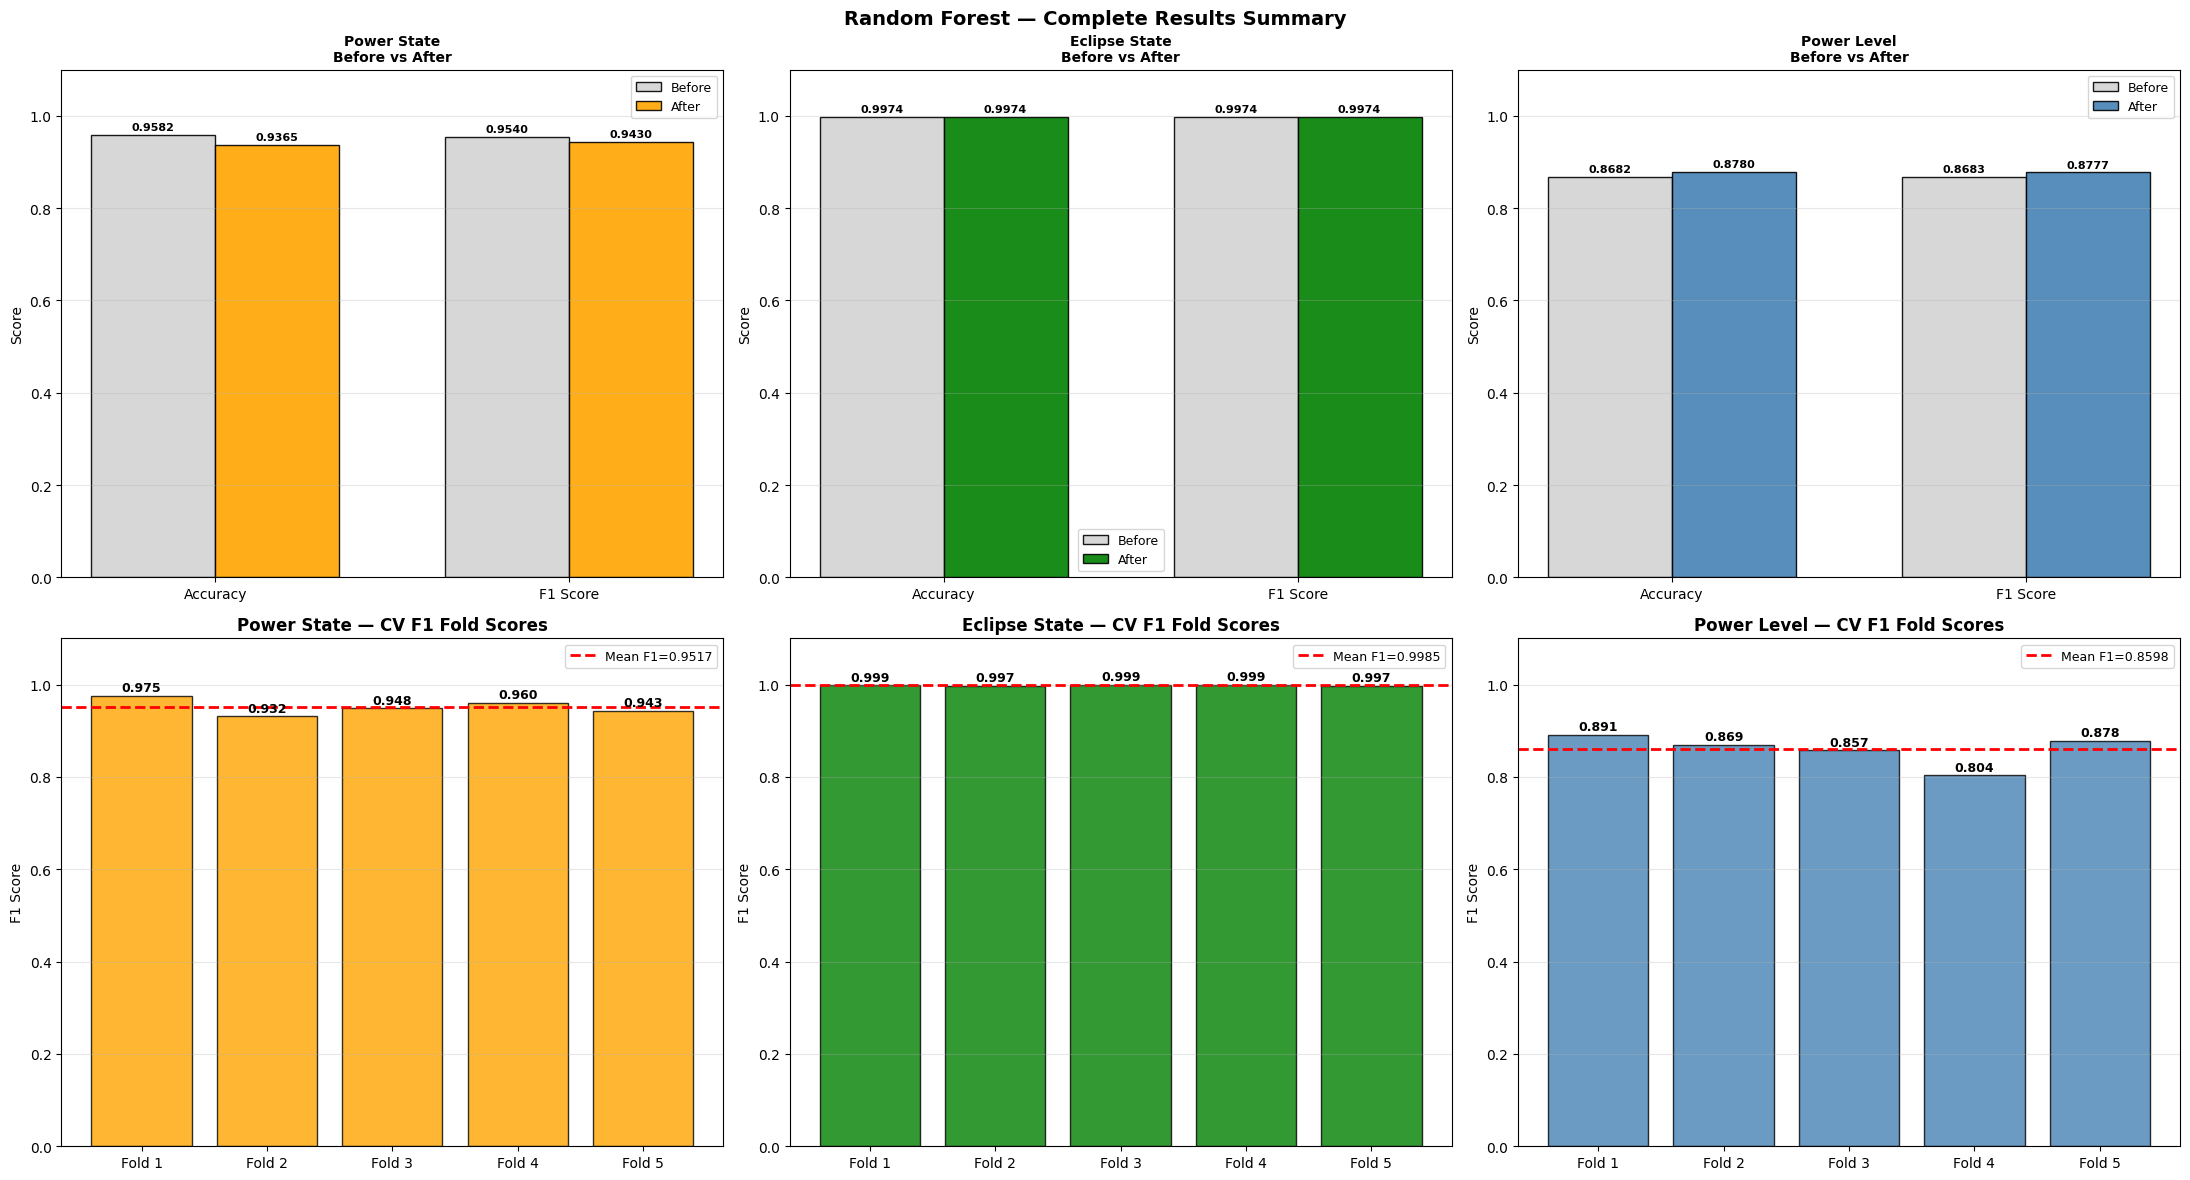

Summary plot saved.


In [11]:
# ============================================================
# SECTION 9: CROSS VALIDATION + COMPLETE SUMMARY
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    model    = results_after[task]['model']
    X_scaled = datasets[task][5].transform(X_full)
    y_full   = df['Power_State']   if task == 'Power_State' \
          else df['Eclipse_State'] if task == 'Eclipse_State' \
          else df['Power_Level']

    scores_acc = cross_val_score(model, X_scaled, y_full,
                                  cv=tscv, scoring='accuracy')
    scores_f1  = cross_val_score(model, X_scaled, y_full,
                                  cv=tscv, scoring='f1_weighted')

    cv_results[task] = {'acc': scores_acc, 'f1': scores_f1}

    print(f"\nTask      : {task}")
    print(f"Acc Folds : {[round(s,4) for s in scores_acc]}")
    print(f"Acc Mean  : {scores_acc.mean():.4f} +/- {scores_acc.std():.4f}")
    print(f"F1 Folds  : {[round(s,4) for s in scores_f1]}")
    print(f"F1 Mean   : {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")

# Summary visualization
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Random Forest — Complete Results Summary',
             fontsize=14, fontweight='bold')

colors    = ['orange', 'green', 'steelblue']
tnames    = ['Power State', 'Eclipse State', 'Power Level']
fold_lbls = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']

# Row 1: Before vs After
for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[0, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']
    x     = np.arange(2)
    w     = 0.35
    ax.bar(x-w/2, [b_acc, b_f1], w, label='Before',
           color='lightgray', edgecolor='black', alpha=0.9)
    ax.bar(x+w/2, [a_acc, a_f1], w, label='After',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'F1 Score'])
    ax.set_title(f'{tn}\nBefore vs After', fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for val, xpos in zip([b_acc, b_f1, a_acc, a_f1],
                          [-w/2, 1-w/2, w/2, 1+w/2]):
        ax.text(xpos, val+0.01, f'{val:.4f}',
                ha='center', fontsize=8, fontweight='bold')

# Row 2: CV F1 fold scores
for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax     = axes[1, idx]
    scores = cv_results[task]['f1']
    bars   = ax.bar(fold_lbls, scores, color=clr,
                    edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean F1={scores.mean():.4f}')
    ax.set_title(f'{tn} — CV F1 Fold Scores', fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{val:.3f}', ha='center',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('05_summary.png', dpi=72, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

## Cross Validation and Complete Results Summary

### Before vs After (Row 1)

Power State accuracy decreased (0.9582 → 0.9365) — intentional
trade-off to improve CRITICAL class recall from 0.05 to 0.56.
F1 also slightly decreased (0.9540 → 0.9430) reflecting the
same trade-off. This is the correct outcome for safety-critical
satellite classification where missing CRITICAL is unacceptable.

Eclipse State remained identical (0.9974 → 0.9974) — already
at ceiling performance. No parameter combination can
meaningfully improve on this result.

Power Level genuinely improved (0.8682 → 0.8780 accuracy,
0.8683 → 0.8777 F1) — the only task where tuning provided
real benefit without any trade-off. Deeper trees with more
feature restriction successfully improved HIGH/MEDIUM separation.

### CV Fold Scores (Row 2)

Power State CV mean = 0.9517 ± 0.0149 — significantly more
stable than Logistic Regression (0.8711 ± 0.0434). Standard
deviation dropped by 3x — bagging effectively smooths out
non-stationary orbital patterns. All folds between 0.931–0.975,
no catastrophic fold collapses seen in LR.

Eclipse State CV mean = 0.9985 ± 0.0009 — the most stable
result in the entire project across all notebooks. Near-perfect
predictions in every orbital time period confirms the
SUNLIGHT/ECLIPSE boundary is consistent throughout the mission.

Power Level CV mean = 0.8598 ± 0.0301 — Fold 4 drops to 0.8038,
the same mid-period orbital instability seen in Logistic
Regression. This is a persistent data characteristic from the
August–October 2021 orbital season where power level
distributions differ from other periods. RF reduces the fold
variance compared to LR but cannot eliminate it without
additional orbital geometry features in the dataset.

## Random Forest Classifier —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**DOI:** 10.1016/j.dib.2022.108697

---

## Algorithm Summary

Random Forest builds multiple decision trees on **bootstrap samples**
of the training data and aggregates their predictions by majority vote:

> ŷ = mode{ h₁(x), h₂(x), ..., hₙ(x) }

Where each hₜ(x) is a decision tree trained on a bootstrap sample.

**Key properties:**
- Each tree uses random subset of features at each split (max_features)
- Bootstrap aggregation (bagging) reduces variance vs single tree
- Feature importance = mean decrease in Gini impurity across all trees
- Does NOT require feature scaling (unlike Logistic Regression)
- f1_macro scoring used in tuning — equal weight to CRITICAL class

**class_weight='balanced'** used for all tasks:
- Compensates for CRITICAL class imbalance (0.7% of data)
- Adjusts class weights inversely proportional to class frequency

---

## Final Results

| Task | n_est | depth | features | Accuracy | F1 Score | CV F1 Mean ± Std |
|------|-------|-------|----------|---------|---------|-----------------|
| Power State | 356 | 10 | 0.5 | 0.9365 | 0.9430 | 0.9517 ± 0.0149 |
| Eclipse State | 393 | 7 | log2 | 0.9974 | 0.9974 | 0.9985 ± 0.0009 |
| Power Level | 276 | 20 | 0.3 | 0.8780 | 0.8777 | 0.8598 ± 0.0301 |

---

## Comparison with Logistic Regression

| Task | LR F1 | RF F1 | Change |
|------|-------|-------|--------|
| Power State | 0.8650 | 0.9430 | +7.80% ✅ |
| Eclipse State | 0.9959 | 0.9974 | +0.15% ✅ |
| Power Level | 0.8599 | 0.8777 | +1.78% ✅ |

**RF beats Logistic Regression on ALL three tasks.**

---

## Key Findings

### 1 — Bagging Reduces Variance by 3x vs Logistic Regression
Power State CV std dropped from 0.0434 (LR) to 0.0149 (RF).
Each tree trained on a different bootstrap sample — individual
tree errors cancel out in majority vote. Bagging effectively
smooths non-stationary orbital patterns that destabilized LR.

### 2 — CRITICAL Class: Necessary Accuracy Trade-off
Base model CRITICAL recall = 0.05 — only 2 out of 39 caught.
After tuning with f1_macro: CRITICAL recall = 0.56 (22/39).
Overall accuracy dropped from 0.9582 to 0.9365 — intentional.
For satellite operations, missing a CRITICAL battery state is
far more dangerous than occasional misclassification of normal
states. The trade-off is correct and necessary.

### 3 — V_panel_avg Dominant Feature Across ALL Tasks
```
Power State  : V_panel_avg = 0.239 (24%)
Eclipse State: V_panel_avg = 0.266 (27%)
Power Level  : V_panel_avg = 0.178 (18%)
```
Average panel voltage ranks first in all three tasks —
confirming it is the single most physically meaningful sensor
reading for satellite power management. Feature engineering
decisions from EDA are validated by ensemble importance scores.

### 4 — RF Resolves HIGH/MEDIUM Overlap vs LR
LR HIGH class recall = 0.63 — linear boundary insufficient.
RF HIGH class recall = 0.77 — non-linear splits successfully
capture the HIGH/MEDIUM power level boundary. This is the
most significant qualitative improvement over LR.

### 5 — Eclipse State at Performance Ceiling
F1 = 0.9974, CV mean = 0.9985 ± 0.0009 — most stable result
in the project. depth=5 is sufficient — 5 split levels capture
the panel voltage threshold between sunlight and eclipse.
Any max_features option achieves 0.997+ confirming task
is trivially separable with any reasonable configuration.

### 6 — n_estimators Plateau Points
```
Power State  : Plateau after n=150
Eclipse State: Perfect at n=50
Power Level  : Plateau after n=300
```
RandomizedSearch found n=356, 393, 276 — all beyond plateau
points confirming stable, converged ensemble predictions.

### 7 — Power Level Fold 4 Persists as Data Issue
Fold 4 F1 = 0.8038 — same mid-period orbital instability
from August–October 2021 seen in Logistic Regression.
RF reduces the variance (LR std=0.0434 vs RF std=0.0301)
but cannot resolve it without additional orbital geometry
features not present in the TSURU dataset.

### 8 — Large Eclipse Feature Importance Error Bars
All panel voltages show high variance in Eclipse importance —
different trees use different panel voltages to make the same
correct prediction. Any individual panel voltage is sufficient
to identify eclipse, making the task robust to sensor failure.
This has practical value — if one panel sensor fails, the
remaining panels still enable reliable eclipse detection.

---

## Limitations
- Slower training and inference than Logistic Regression
- Less interpretable — no signed directional coefficients
- Memory intensive with 356–393 trees per task
- CRITICAL recall = 0.56 — still misses 17 out of 39 samples
- Power Level Fold 4 instability cannot be resolved without
  additional orbital geometry features
- Bootstrap sampling may under-represent CRITICAL in some trees

---

*Reference: Jara et al. (2022), Data in Brief, DOI: 10.1016/j.dib.2022.108697*